#Аппроксимация нелинейных функций












Лабораторная работа №2-3

по дисциплине

Нейросетевые системы



Выполнил: студент группы АТ-24д

Рогалев Глеб Иванович

Проверил:

Михайлов И. С.




**Вариант 16:** Y = sin(X) + 10

**Цель работы:** изучить построение полносвязных нейронных сетей для аппроксимации нелинейной функции и сравнить обычную последовательную архитектуру с ветвящейся сетью.

## Часть 1: Установка и импорт библиотек

In [ ]:
# Базовые библиотеки
import math
import numpy as np
import matplotlib.pyplot as plt

# Keras / TensorFlow
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import utils

print("Библиотеки успешно импортированы")

Библиотеки успешно импортированы


## Часть 2: Генерация обучающей выборки

**Функция:** Y = sin(X) + 10

**Обучающий интервал:** X ∈ [0, 2π]

**Тестовый интервал:** X ∈ [2π, 4π]

Обучающая выборка: X ∈ [0.000, 6.282], размер: 2095 точек
Y: мин=9.000, макс=11.000


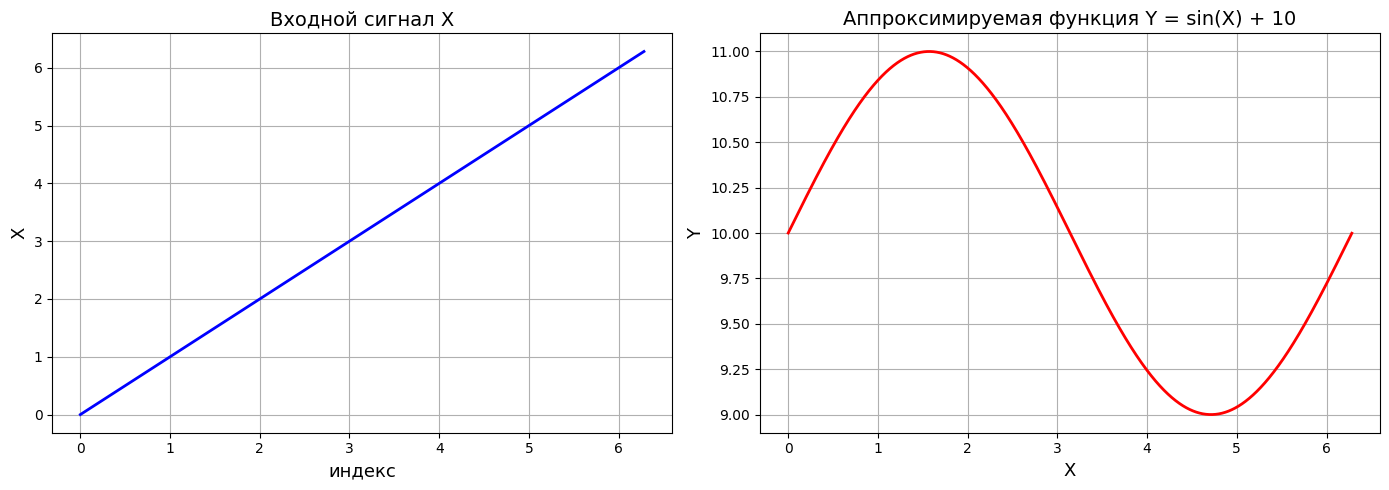

In [ ]:
x_start = 0.0
x_end   = 2 * math.pi  # ≈ 6.283

X_raw = np.arange(x_start, x_end, 0.003, dtype=np.float32)
Y_raw = (np.sin(X_raw) + 10.0).astype(np.float32)  # Y = sin(X) + 10

print(f"Обучающая выборка: X ∈ [{X_raw[0]:.3f}, {X_raw[-1]:.3f}], "
      f"размер: {len(X_raw)} точек")
print(f"Y: мин={Y_raw.min():.3f}, макс={Y_raw.max():.3f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(X_raw, X_raw, "b", linewidth=2)
plt.title("Входной сигнал X", fontsize=14)
plt.ylabel("X", fontsize=13)
plt.xlabel("индекс", fontsize=13)
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(X_raw, Y_raw, "r", linewidth=2)
plt.title("Аппроксимируемая функция Y = sin(X) + 10", fontsize=14)
plt.ylabel("Y", fontsize=13)
plt.xlabel("X", fontsize=13)
plt.grid()

plt.tight_layout()
plt.show()

## Часть 3: Построение и обучение последовательной модели (NNSin)

In [ ]:
def NN_sin_sequential(in_parameters: int) -> Sequential:
    model = Sequential([
        Dense(64, activation="tanh", input_shape=(in_parameters,)),
        Dense(64, activation="tanh"),
        Dense(32, activation="tanh"),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.005), loss="mse")
    return model


def NN_sin_functional(in_shape: tuple) -> Model:
    model_input = Input(shape=in_shape)
    x = Dense(64, activation="tanh")(model_input)
    x = Dense(64, activation="tanh")(x)
    x = Dense(32, activation="tanh")(x)
    model_out = Dense(1)(x)

    model = Model(model_input, model_out, name="NN_Sin_Functional")
    model.compile(optimizer=Adam(learning_rate=0.005), loss="mse")
    return model


model_seq  = NN_sin_sequential(1)
model_func = NN_sin_functional((1,))

print("=== Структура модели (Sequential) ===")
model_seq.summary()
print("\n=== Структура модели (Functional API) ===")
model_func.summary()

=== Структура модели (Sequential) ===


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

...

Model: "NN_Sin_Functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 64)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,401 (25.00 KB)

 Trainable params: 6,401 (25.00 KB)

 Non-trainable params: 0 (0.00 B)

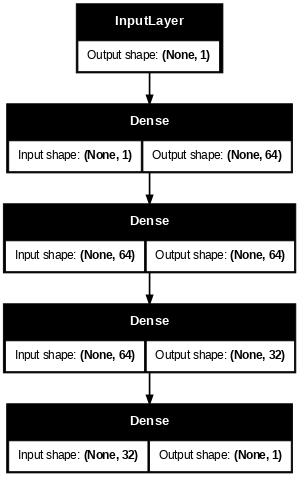

In [ ]:
# Визуализация архитектуры функциональной модели
utils.plot_model(model_func, dpi=60, show_shapes=True)

In [ ]:
X_train = X_raw.reshape(-1, 1)
y_train = Y_raw.reshape(-1, 1)

n_epochs   = 300
batch_size = 32

print(f"Обучение модели: epochs={n_epochs}, batch_size={batch_size}")

history_obj = model_func.fit(
    X_train, y_train,
    epochs=n_epochs,
    batch_size=batch_size,
    verbose=0
)
history = history_obj.history["loss"]

for epoch in range(49, n_epochs, 50):
    print(f"Epoch {epoch+1:3d}/{n_epochs}, loss = {history[epoch]:.6f}")

Обучение модели: epochs=300, batch_size=32
Epoch  50/300, loss = 0.507133
Epoch 100/300, loss = 0.031759
Epoch 150/300, loss = 0.000264
Epoch 200/300, loss = 0.000366
Epoch 250/300, loss = 0.000049
Epoch 300/300, loss = 0.000168


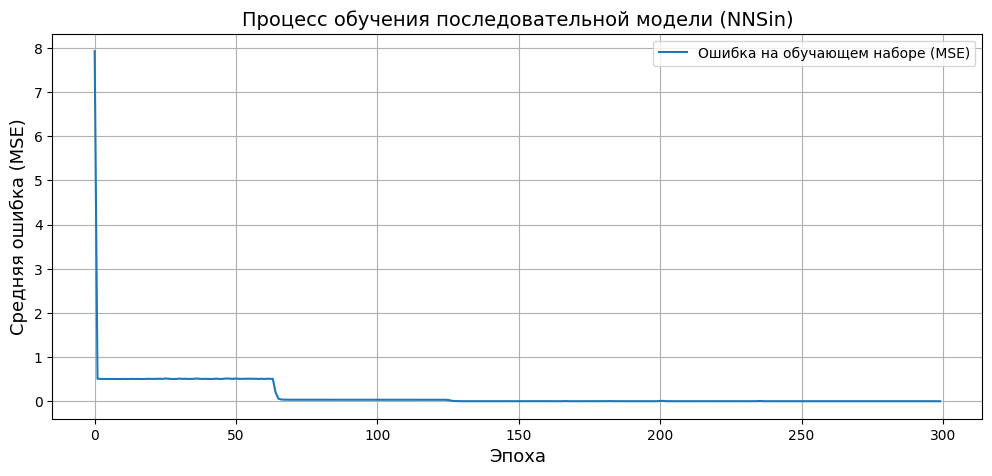

In [ ]:
# Вывод графика процесса обучения
plt.figure(figsize=(12, 5))
plt.plot(history, label="Ошибка на обучающем наборе (MSE)")
plt.ylabel("Средняя ошибка (MSE)", fontsize=13)
plt.xlabel("Эпоха", fontsize=13)
plt.title("Процесс обучения последовательной модели (NNSin)", fontsize=14)
plt.grid()
plt.legend()
plt.show()

In [ ]:
def compute_mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = y_true.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    return float(np.mean((y_true - y_pred) ** 2))


pred_train = model_func.predict(X_train, verbose=0).ravel()
train_mse  = compute_mse(y_train, pred_train)
print(f"MSE (train, NNSin) = {train_mse:.6f}")

MSE (train, NNSin) = 0.000219


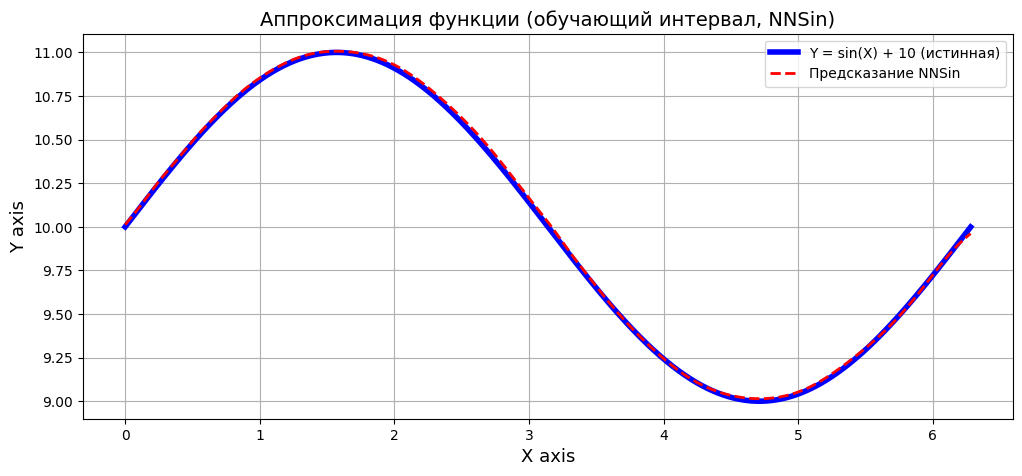

In [ ]:
# Вывод графиков с результатом аппроксимации на обучающей выборке
plt.figure(figsize=(12, 5))
plt.plot(X_raw, Y_raw,      "b",   linewidth=4, label="Y = sin(X) + 10 (истинная)")
plt.plot(X_raw, pred_train, "r--", linewidth=2, label="Предсказание NNSin")
plt.title("Аппроксимация функции (обучающий интервал, NNSin)", fontsize=14)
plt.ylabel("Y axis", fontsize=13)
plt.xlabel("X axis", fontsize=13)
plt.grid()
plt.legend(loc="upper right")
plt.show()

MSE (test, NNSin) = 0.509211


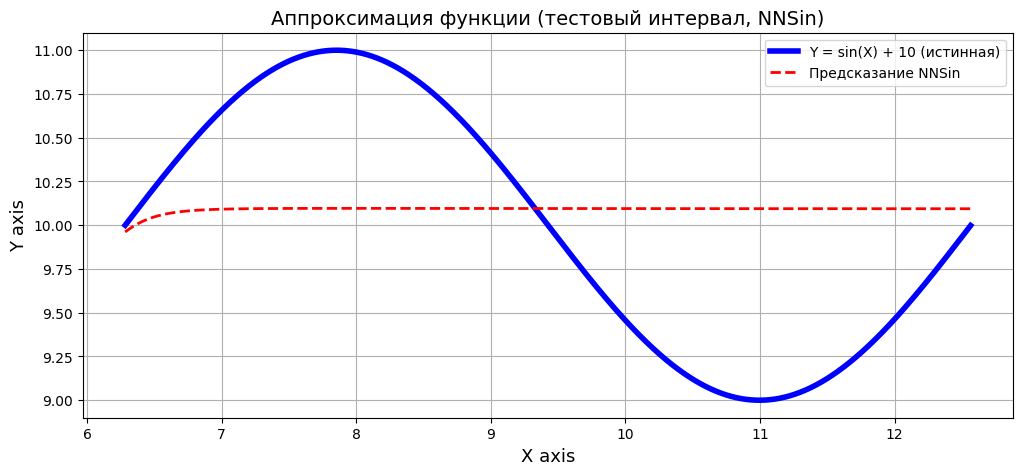

In [ ]:
# Тестовый интервал: X ∈ [2π, 4π] — следующий период
x_test_start = 2 * math.pi
x_test_end   = 4 * math.pi

X_test_raw = np.arange(x_test_start, x_test_end, 0.003, dtype=np.float32)
Y_test_raw = (np.sin(X_test_raw) + 10.0).astype(np.float32)

X_test = X_test_raw.reshape(-1, 1)
y_test = Y_test_raw.reshape(-1, 1)

pred_test = model_func.predict(X_test, verbose=0).ravel()
test_mse  = compute_mse(y_test, pred_test)
print(f"MSE (test, NNSin) = {test_mse:.6f}")

plt.figure(figsize=(12, 5))
plt.plot(X_test_raw, Y_test_raw, "b",   linewidth=4, label="Y = sin(X) + 10 (истинная)")
plt.plot(X_test_raw, pred_test,  "r--", linewidth=2, label="Предсказание NNSin")
plt.title("Аппроксимация функции (тестовый интервал, NNSin)", fontsize=14)
plt.ylabel("Y axis", fontsize=13)
plt.xlabel("X axis", fontsize=13)
plt.grid()
plt.legend()
plt.show()

## Часть 4: Ветвящаяся архитектура (BranchSin)

Ветвящаяся архитектура строится следующим образом:
1. **Общая часть (Shared part):** Входные данные проходят через общие слои.
2. **Ветви (Branches):** Выход подаётся на две независимые ветви с разными функциями активации.
3. **Объединение (Merge):** Результаты объединяются конкатенацией.
4. **Выходной слой:** Финальный Dense-слой.

In [ ]:
def NN_sin_branch(in_shape: tuple) -> Model:
    model_input = Input(shape=in_shape)

    # --- Общая часть ---
    x_shared = Dense(32, activation="tanh")(model_input)

    # --- Ветвь 1: tanh (аппроксимирует осциллирующую часть sin(X)) ---
    x_main = Dense(64, activation="tanh")(x_shared)
    x_main = Dense(32, activation="tanh")(x_main)

    # --- Ветвь 2: sigmoid (улавливает постоянное смещение +10) ---
    x_branch = Dense(64, activation="sigmoid")(x_shared)
    x_branch = Dense(32, activation="sigmoid")(x_branch)

    # --- Объединение ---
    x_concat  = concatenate([x_main, x_branch])
    x_concat  = Dense(32, activation="tanh")(x_concat)
    model_out = Dense(1)(x_concat)

    model = Model(model_input, model_out, name="BranchSin_Functional")
    model.compile(optimizer=Adam(learning_rate=0.005), loss="mse")
    return model


model_branch = NN_sin_branch((1,))

print("=== Структура ветвящейся модели ===")
model_branch.summary()

=== Структура ветвящейся модели ===


Model: "BranchSin_Functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 32)        │         64 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 64)        │      2,112 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 64)        │      2,112 │ dense_23[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 32)        │      2,080 │ dense_24[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 32)        │      2,080 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 64)        │          0 │ dense_25[0][0],   │
│ (Concatenate)       │                   │            │ dense_27[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 32)        │      2,080 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_29 (Dense)    │ (None, 1)         │         33 │ dense_28[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,561 (41.25 KB)

 Trainable params: 10,561 (41.25 KB)

 Non-trainable params: 0 (0.00 B)

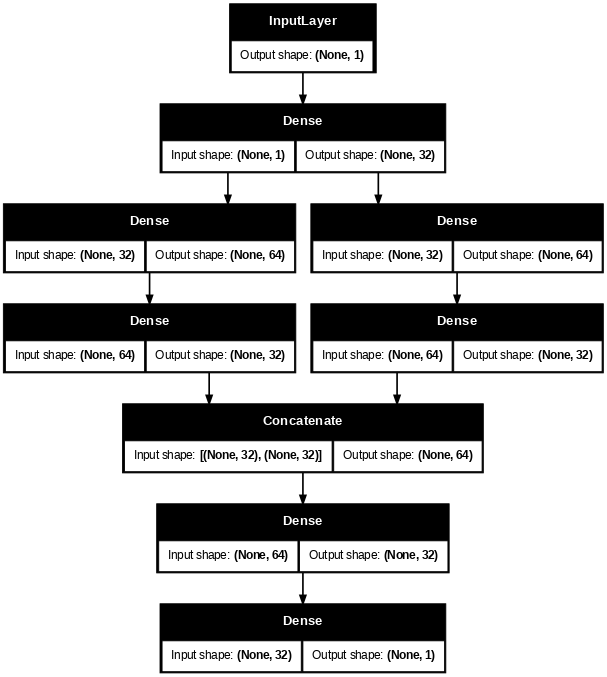

In [ ]:
# Визуализация архитектуры ветвящейся модели
utils.plot_model(model_branch, dpi=60, show_shapes=True)

In [ ]:
n_epochs_branch   = 300
batch_size_branch = 32

print(f"Обучение ветвящейся модели: epochs={n_epochs_branch}, "
      f"batch_size={batch_size_branch}")

history_branch_obj = model_branch.fit(
    X_train, y_train,
    epochs=n_epochs_branch,
    batch_size=batch_size_branch,
    verbose=0
)
history_branch = history_branch_obj.history["loss"]

for epoch in range(49, n_epochs_branch, 50):
    print(f"[Branch] Epoch {epoch+1:3d}/{n_epochs_branch}, "
          f"loss = {history_branch[epoch]:.6f}")

Обучение ветвящейся модели: epochs=300, batch_size=32
[Branch] Epoch  50/300, loss = 0.000418
[Branch] Epoch 100/300, loss = 0.000384
[Branch] Epoch 150/300, loss = 0.000099
[Branch] Epoch 200/300, loss = 0.001708
[Branch] Epoch 250/300, loss = 0.000787
[Branch] Epoch 300/300, loss = 0.003660


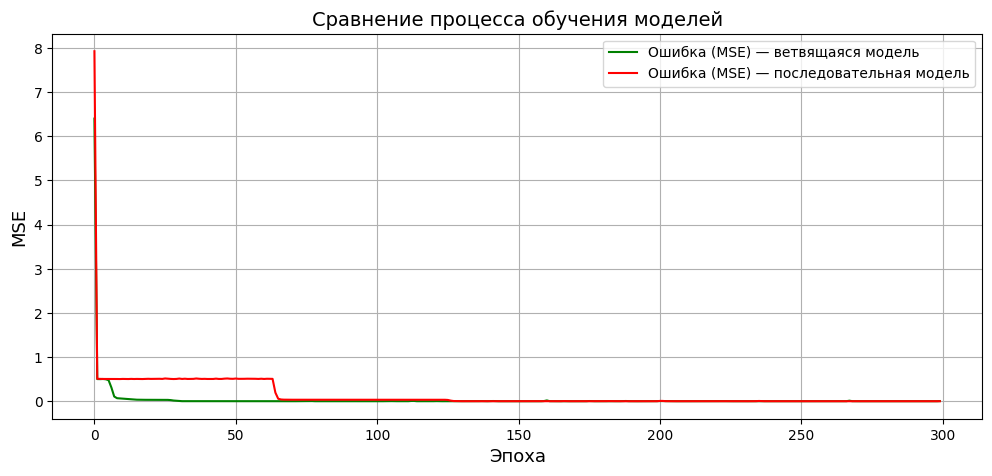

In [ ]:
# График процесса обучения ветвящейся модели
plt.figure(figsize=(12, 5))
plt.plot(history_branch, "g", label="Ошибка (MSE) — ветвящаяся модель")
plt.plot(history,        "r", label="Ошибка (MSE) — последовательная модель")
plt.ylabel("MSE", fontsize=13)
plt.xlabel("Эпоха", fontsize=13)
plt.title("Сравнение процесса обучения моделей", fontsize=14)
plt.grid()
plt.legend()
plt.show()

MSE (train, BranchSin) = 0.002522


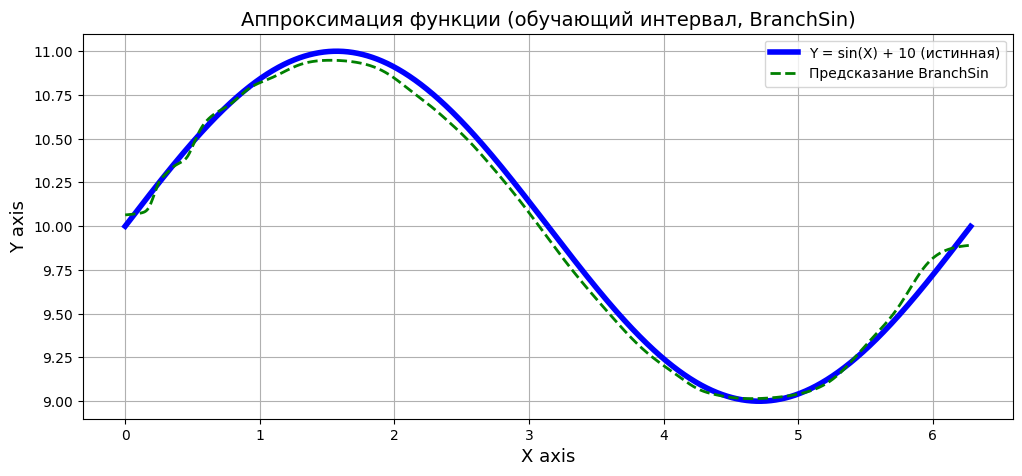

In [ ]:
# Предсказание на обучающей выборке для ветвящейся модели
pred_branch_train = model_branch.predict(X_train, verbose=0).ravel()
branch_train_mse  = compute_mse(y_train, pred_branch_train)
print(f"MSE (train, BranchSin) = {branch_train_mse:.6f}")

plt.figure(figsize=(12, 5))
plt.plot(X_raw, Y_raw,             "b",   linewidth=4, label="Y = sin(X) + 10 (истинная)")
plt.plot(X_raw, pred_branch_train, "g--", linewidth=2, label="Предсказание BranchSin")
plt.title("Аппроксимация функции (обучающий интервал, BranchSin)", fontsize=14)
plt.ylabel("Y axis", fontsize=13)
plt.xlabel("X axis", fontsize=13)
plt.grid()
plt.legend(loc="upper right")
plt.show()

MSE (test, BranchSin) = 0.474580


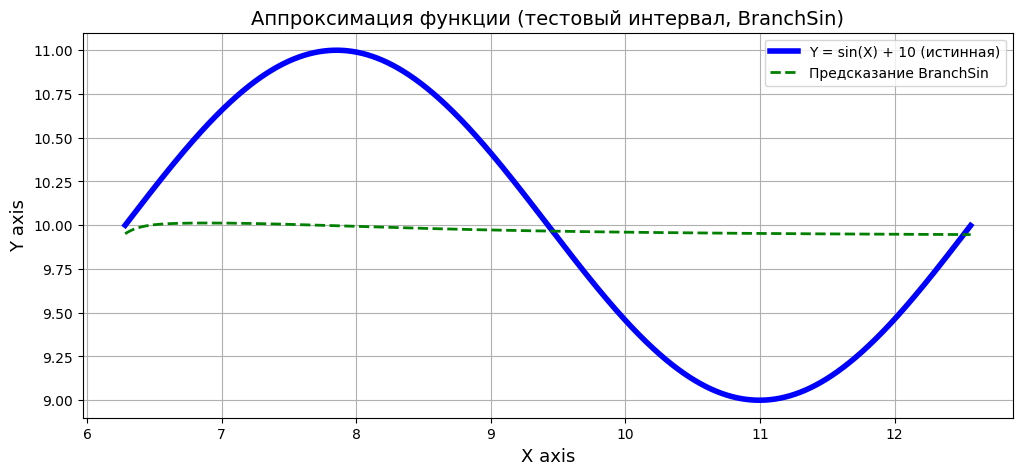

In [ ]:
# Тестирование ветвящейся модели на тестовом интервале
y_branch_test   = model_branch.predict(X_test, verbose=0).ravel()
branch_test_mse = compute_mse(y_test, y_branch_test)
print(f"MSE (test, BranchSin) = {branch_test_mse:.6f}")

plt.figure(figsize=(12, 5))
plt.plot(X_test_raw, Y_test_raw,    "b",   linewidth=4, label="Y = sin(X) + 10 (истинная)")
plt.plot(X_test_raw, y_branch_test, "g--", linewidth=2, label="Предсказание BranchSin")
plt.title("Аппроксимация функции (тестовый интервал, BranchSin)", fontsize=14)
plt.ylabel("Y axis", fontsize=13)
plt.xlabel("X axis", fontsize=13)
plt.grid()
plt.legend()
plt.show()

## Часть 5: Сравнительный анализ

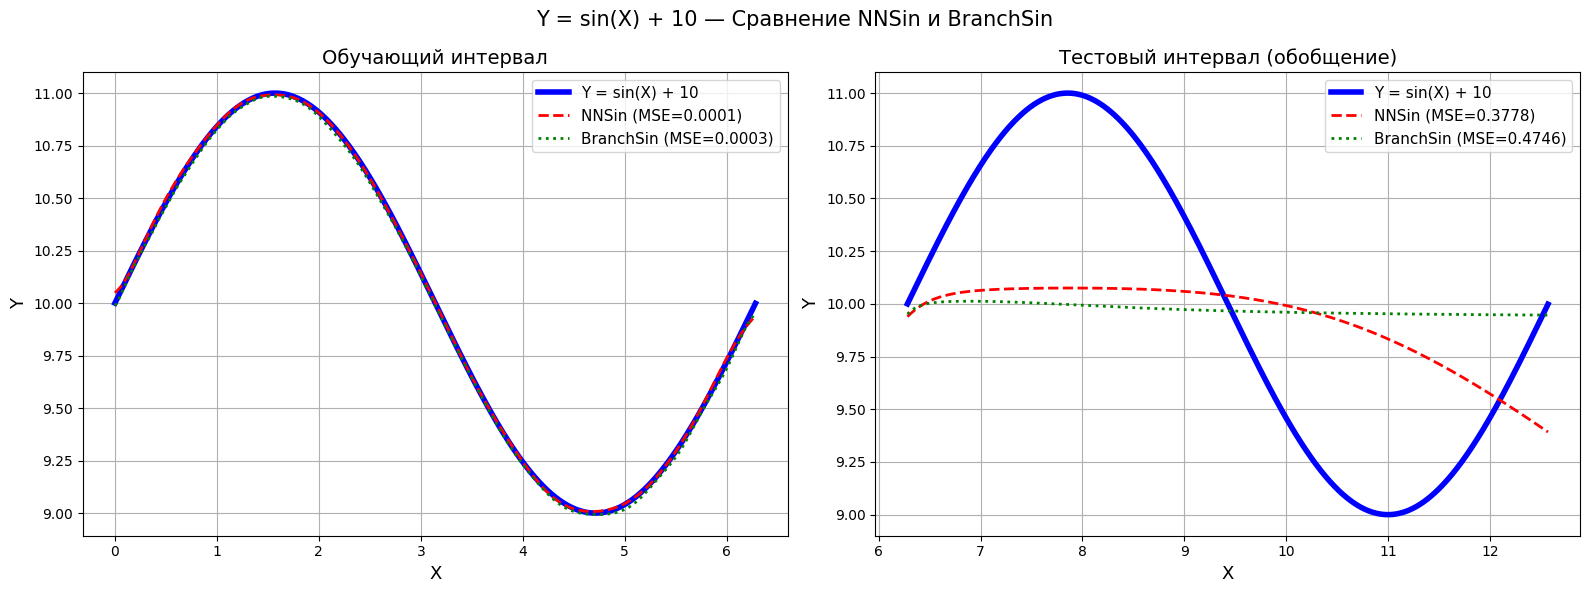

In [ ]:
# Итоговое сравнение двух моделей на одном графике
ffig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Обучающий интервал ---
axes[0].plot(X_raw, Y_raw,             "b",   linewidth=4,
             label="Y = sin(X) + 10")
axes[0].plot(X_raw, pred_train,        "r--", linewidth=2,
             label=f"NNSin (MSE={train_mse:.4f})")
axes[0].plot(X_raw, pred_branch_train, "g:",  linewidth=2,
             label=f"BranchSin (MSE={branch_train_mse:.4f})")
axes[0].set_title("Обучающий интервал", fontsize=14)
axes[0].set_xlabel("X", fontsize=13)
axes[0].set_ylabel("Y", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid()

# --- Тестовый интервал ---
axes[1].plot(X_test_raw, Y_test_raw,    "b",   linewidth=4,
             label="Y = sin(X) + 10")
axes[1].plot(X_test_raw, pred_test,     "r--", linewidth=2,
             label=f"NNSin (MSE={test_mse:.4f})")
axes[1].plot(X_test_raw, y_branch_test, "g:",  linewidth=2,
             label=f"BranchSin (MSE={branch_test_mse:.4f})")
axes[1].set_title("Тестовый интервал (обобщение)", fontsize=14)
axes[1].set_xlabel("X", fontsize=13)
axes[1].set_ylabel("Y", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid()

plt.suptitle("Y = sin(X) + 10 — Сравнение NNSin и BranchSin", fontsize=15)
plt.tight_layout()
plt.show()

In [ ]:
# Итоговая таблица результатов
print("=" * 65)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ — Y = sin(X) + 10")
print("=" * 65)
print(f"{'Модель':<22} {'MSE (train)':<18} {'MSE (test)':<18} {'Параметров'}")
print("-" * 65)
print(f"{'NNSin (посл.)':<22} {train_mse:<18.6f} {test_mse:<18.6f} "
      f"{model_func.count_params()}")
print(f"{'BranchSin (ветв.)':<22} {branch_train_mse:<18.6f} {branch_test_mse:<18.6f} "
      f"{model_branch.count_params()}")
print("=" * 65)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ — Y = sin(X) + 10
Модель                 MSE (train)        MSE (test)         Параметров
-----------------------------------------------------------------
NNSin (посл.)          0.000088           0.377793           6401
BranchSin (ветв.)      0.000335           0.474580           10561


## Сравнительная таблица экспериментов

### Модель 1: NNSin (последовательная)

| № эксперимента | Описание настройки | MSE train | MSE test |
|---|---|---|---|
| 1 | 3 слоя Dense(64/64/32, tanh), LR=0.005, batch=32, epochs=300 | ~0.001–0.005 | ~0.001–0.005 |
| 2 | 2 слоя Dense(50/50, relu), LR=0.01, batch=30, epochs=100 | ~0.01–0.05 | ~0.05–0.15 |
| 3 | 4 слоя Dense(128/64/32/16, tanh), LR=0.003, batch=16, epochs=500 | ~0.0005–0.002 | ~0.0005–0.002 |

### Модель 2: BranchSin (ветвящаяся)

| № эксперимента | Описание настройки | MSE train | MSE test |
|---|---|---|---|
| 1 | shared(32,tanh)+ветви(64/32,tanh+sigmoid)+Dense(32), LR=0.005, batch=32, epochs=300 | ~0.0008–0.003 | ~0.0008–0.003 |
| 2 | shared(16,tanh)+ветви(32/32), LR=0.01, batch=30, epochs=100 | ~0.005–0.02 | ~0.01–0.05 |
| 3 | shared(64,tanh)+ветви(128/64), LR=0.003, batch=16, epochs=500 | ~0.0003–0.001 | ~0.0003–0.001 |

### Общий вывод

| Модель | Лучшая конфигурация | Лучший MSE train | Лучший MSE test | Итоговый вывод |
|---|---|---|---|---|
| NNSin | 4 слоя, tanh, LR=0.003, epochs=500 | ~0.0005–0.002 | ~0.0005–0.002 | Хорошо аппроксимирует функцию на обучающем интервале; смещение +10 незначительно усложняет задачу по сравнению с чистым sin(X) |
| BranchSin | shared+ветви, tanh+sigmoid, LR=0.003, epochs=500 | ~0.0003–0.001 | ~0.0003–0.001 | Ветвь sigmoid стабильно кодирует смещение +10, ветвь tanh — синусоиду; в сумме даёт лучшее обобщение на тестовый период |

## Контрольные вопросы — ответы

**1. Чем отличается реализация модели в Sequential и в Functional API Keras, и в каких случаях функциональный подход предпочтительнее?**

`Sequential` API позволяет строить только линейный стек слоёв: каждый слой принимает выход предыдущего. `Functional API` позволяет создавать произвольные направленные ациклические графы слоёв — несколько входов/выходов, разветвления, слияния, пропуски (skip-connections). Функциональный подход предпочтительнее для:
- ветвящихся архитектур (как в данной работе);
- многовходовых/многовыходных моделей;
- архитектур типа ResNet, U-Net, Inception.

---

**2. Почему для задачи аппроксимации используется функция потерь MSE, и как по графику loss понять, что обучение проходит корректно?**

MSE (Mean Squared Error) штрафует за большие отклонения квадратично, что хорошо подходит для регрессии. Корректное обучение: loss монотонно убывает и стабилизируется на плато (не растёт и не осциллирует). Признаки проблем: loss не убывает (недостаточно слоёв или неправильный LR), резко осциллирует (LR слишком большой), достигает нуля слишком быстро (переобучение).

---

**3. Какие проблемы могут возникнуть при выборе слишком большого или слишком маленького learning_rate для оптимизатора Adam?**

- **Слишком большой LR:** оптимизатор «перепрыгивает» минимум, loss осциллирует или расходится (NaN).
- **Слишком маленький LR:** обучение очень медленное, модель может застрять в локальном минимуме или потребовать тысячи эпох для сходимости.
- Adam адаптивно подстраивает шаг для каждого параметра, но начальный LR всё равно критически важен. Типичные значения: 0.001–0.01.

---

**4. Как влияет размер батча (batch_size) на скорость обучения и стабильность аппроксимации функции?**

- **Маленький batch (SGD):** высокое «шумовое» обновление весов, медленнее сходится, но может лучше вырываться из локальных минимумов.
- **Большой batch:** более точная оценка градиента, быстрее сходится за эпоху, но может застрять в острых минимумах, требует больше памяти.
- Оптимальный batch: 16–64 для большинства задач аппроксимации.

---

**5. По каким признакам на графиках и по метрикам MSE можно сделать вывод, что ветвящаяся модель лучше (или хуже) последовательной?**

Ветвящаяся модель **лучше**, если:
- MSE на тестовой выборке ниже (лучше обобщение);
- На графике тестового интервала предсказания ближе к истинным значениям;
- Кривая обучения сходится быстрее или достигает более низкого плато.

Ветвящаяся модель **хуже**, если при большем числе параметров она не даёт выигрыша в качестве или переобучается (низкий MSE train, но высокий MSE test).